In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.linalg import pinv, qr
from scipy.linalg import svd
from mpl_toolkits.mplot3d import Axes3D
import warnings
from scipy import stats
from scipy.stats import bootstrap


warnings.filterwarnings('ignore')
plt.rcParams.update({'font.size': 26})


In [2]:
def jac_reservoir(r, Wo, Wi, Wh, b):
    A = Wh + Wi @ Wo              # (h x h)
    Ar = A @ r + b                # (h x 1)
    sech2 = 1 / np.cosh(Ar)**2    # (h x 1)
    jac = A * sech2               # Broadcast sech² element-wise across rows of A
    return jac


def bootstrp(nboot, func, data):
    """Bootstrap resampling equivalent to MATLAB bootstrp"""
    n = len(data)
    results = []
    for _ in range(nboot):
        # Resample with replacement
        indices = np.random.choice(n, size=n, replace=True)
        sample = data[indices]
        results.append(func(sample))
    return np.array(results)

def bootci(nboot, func, data, alpha=0.05):
    """Bootstrap confidence intervals equivalent to MATLAB bootci"""
    boot_stats = bootstrp(nboot, func, data)
    if boot_stats.ndim == 1:
        boot_stats = boot_stats.reshape(-1, 1)
    
    ci_lower = np.percentile(boot_stats, 100 * alpha/2, axis=0)
    ci_upper = np.percentile(boot_stats, 100 * (1 - alpha/2), axis=0)
    return np.vstack([ci_lower, ci_upper])

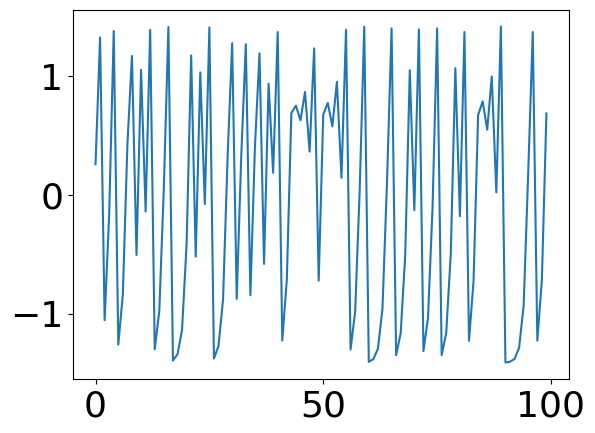

In [3]:
def logistic_map(r, x0, T, tT=0):
    N = T + tT
    x = np.empty(N + 1)
    x[0] = x0
    for n in range(N):
        x[n+1] = r * x[n] * (1 - x[n])
    return x[tT+1:]  # discard transient

# Parameters
r = 4.
x0 = 0.2
T = 80000
tT = 20

y = logistic_map(r, x0, T, tT)

U = (y - np.mean(y)) / np.std(y)
U = U.reshape(-1, 1)

plt.figure()
plt.plot(U[:100, 0])
plt.show()

strain = U[:int(np.floor(U.shape[0]/2)), :]
stest = U[int(np.floor(U.shape[0]/2)):, :]
dim = 1
dt = 1

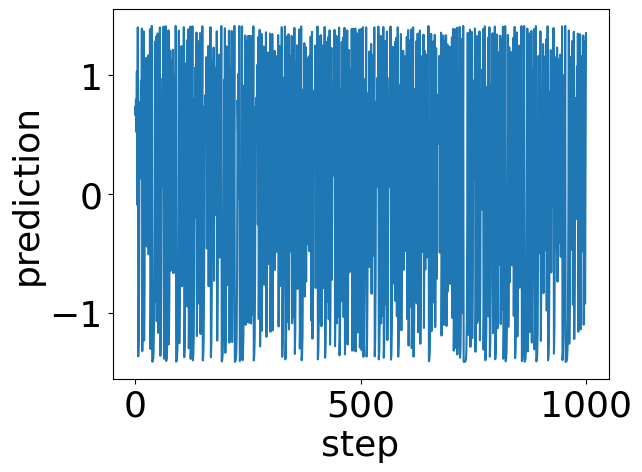

In [4]:
strain = U[:int(np.floor(U.shape[0]/2)), :]
stest = U[int(np.floor(U.shape[0]/2)):, :]
dim = 1

# Train an echo state network with hidden bias (uniform distribution)
seed = 10
np.random.seed(seed)
h = 100  # hidden width
kh = 0#1/100#10**-2.7
ki = 1.#5.#0.6
kb = ki#.01#1.7#0.2

Wh = kh * np.random.randn(h, h)  # hidden-to-hidden
Wi = ki * np.random.randn(h, dim)  # input-to-hidden
b = kb * np.random.randn(h, 1)  # hidden bias

trainnum = strain.shape[0]
hiddens = np.zeros((h, trainnum))
rs = -kh + (2*kh) * np.random.rand(h, 1)

for i in range(trainnum):
    rs = np.tanh(Wh @ rs + Wi @ strain[i, :].reshape(-1, 1) + b)
    hiddens[:, i] = rs.flatten()

convnum = 1000  # step when a hidden state converges
Wo = strain[convnum:, :].T @ pinv(hiddens[:, convnum-1:-1])

# Prediction
seed = 0
np.random.seed(seed)
idx = np.random.randint(0, stest.shape[0] - convnum)
prednum = strain.shape[0]
preds = np.zeros((3, prednum))
rs = -np.sqrt(kh) + (2*np.sqrt(kh)) * np.random.rand(h, 1)

for i in range(convnum):
    rs = np.tanh(Wh @ rs + Wi @ strain[idx+i, :].reshape(-1, 1) + b)

pred = Wo @ rs

for i in range(prednum):
    rs = np.tanh(Wh @ rs + Wi @ pred + b)
    pred = Wo @ rs
    preds[:, i] = pred.flatten()

x = preds[0, :1000]
plt.figure()
plt.plot(x)
plt.xlabel('step')
plt.ylabel('prediction')
plt.show()

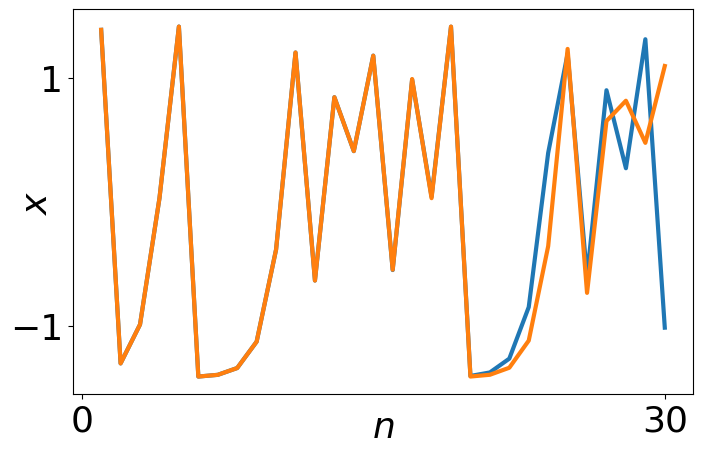

In [5]:
# Plot test prediction
lmax = np.log(2) # largest lyapunov exponent
preds_test = []
true_test = []
deltas = []

for i in range(1):
    idx = 0#np.random.randint(0, stest.shape[0] - int(10/dt))
    count = 1
    delta = 0
    
    for j in range(convnum+1):
        rs = np.tanh(Wh @ rs + Wi @ stest[idx+j, :].reshape(-1, 1) + b)
    
    pred = Wo @ rs
    delta = np.linalg.norm(pred - stest[idx+convnum+count, :].reshape(-1, 1))
    deltas.append(delta)
    true_test.append(stest[idx+convnum+count, :])
    preds_test.append(pred.flatten())
    count += 1
    
#     while delta <= 1.:
    while count <= 30:
        rs = np.tanh(Wh @ rs + Wi @ pred + b)
        pred = Wo @ rs
        delta = np.linalg.norm(pred - stest[idx+convnum+count, :].reshape(-1, 1))
        deltas.append(delta)
        true_test.append(stest[idx+convnum+count, :])
        preds_test.append(pred.flatten())
        count += 1
true_test = np.array(true_test).T
preds_test = np.array(preds_test).T
deltas = np.array(deltas)

lyapt = np.arange(1, true_test.shape[1]+1) #* dt * lmax
plt.figure(figsize=[8,5])
plt.plot(lyapt, true_test[0, :], lyapt, preds_test[0, :],lw=3)
# plt.xlabel('t*λ_max')
plt.xlabel('$n$', labelpad=-20)
plt.ylabel('$x$', labelpad=-32)
plt.xticks([0,30])
plt.yticks([-1,1])

plt.show()

In [25]:
# lyapunov spectrum
lyapus = []

seed = 1
np.random.seed(seed)
for loop in range(30):
    test = 1
    while test>0.008:
        h = 100  # hidden width
        kh = 0#1/100#10**-2.7
        ki = 1.#5.#0.6
        kb = ki#.01#1.7#0.2

        Wh = kh * np.random.randn(h, h)  # hidden-to-hidden
        Wi = ki * np.random.randn(h, dim)  # input-to-hidden
        b = kb * np.random.randn(h, 1)  # hidden bias

        trainnum = strain.shape[0]
        hiddens = np.zeros((h, trainnum))
        rs = -kh + (2*kh) * np.random.rand(h, 1)

        for i in range(trainnum):
            rs = np.tanh(Wh @ rs + Wi @ strain[i, :].reshape(-1, 1) + b)
            hiddens[:, i] = rs.flatten()

        convnum = 1000 # step when a hidden state converges
        Wo = strain[convnum:, :].T @ pinv(hiddens[:, convnum-1:-1])

        # %% estimate lyapunov exponents
        prednum = 10**4 # int(T/dt/2)
        preds_lyap = np.zeros((prednum, dim))

        rss = np.zeros((prednum, h))
        idx = 100
        rs = -np.sqrt(kh) + (2*np.sqrt(kh)) * np.random.rand(h, 1)

        for i in range(convnum):
            rs = np.tanh(Wh @ rs + Wi @ strain[idx + i, :].reshape(-1, 1) + b)

        pred = Wo @ rs
        for i in range(prednum):
            rs = np.tanh(Wh @ rs + Wi @ pred + b)
            pred = Wo @ rs
            preds_lyap[i, :] = pred.flatten()[:dim]
            rss[i, :] = rs.flatten()
        # plt.figure(figsize=[3,2])
        # plt.plot(preds_lyap[-100:,0])
        # plt.plot(preds_lyap[:100,0],lw=0.5)
        # plt.show()

        test = stats.ks_2samp(strain.reshape([-1]), preds_lyap.T[0]).statistic
        print(test)


    # %% Forward transient
    n0 = int(15/dt) #int(15/dt)  # steps for transient
    k = 10  # sampling step
    G = np.random.rand(h, h)
    G, _ = qr(G)

    # %%
    for i in range(n0//k):
        for j in range(k):
            J = jac_reservoir(rss[k*i + j, :].reshape(-1, 1), Wo, Wi, Wh, b)
            G = J @ G
        G, R = qr(G)  # QR decomposition
        # k*i+j
    # print('hi')

    # Forward dynamics
    t0 = n0  # backward transient
    t = prednum - n0 - t0  # int(T/2/dt) - n0 - t0
    # t = int(T/10/dt) - n0 - t0
    Glist = np.zeros((h, h, (t + t0)//k - 1))
    Rlist = np.zeros((h, h, (t + t0)//k - 1))
    # S=zeros(dim,(t+t0)/k-1);Gbefore=zeros(dim,dim,(t+t0)/k-1);
    Glist[:, :, 0] = G
    Rlist[:, :, 0] = R
    # S(:,1)=preds(n0,:)';

    for i in range((t + t0)//k - 1):
        for j in range(k):
            J = jac_reservoir(rss[k*i + j + n0, :].reshape(-1, 1), Wo, Wi, Wh, b)
            G = J @ G
        # Gbefore(:,:,i+2)=[G(:,1)/norm(G(:,1)) G(:,2)/norm(G(:,2)) G(:,3)/norm(G(:,3))];
        G, R = qr(G)  # QR decomposition
        Glist[:, :, i] = G
        Rlist[:, :, i] = R
        # S(:,i+2)=preds(k*i+j+n0,:)';

    # %%
    lyapu_all = np.zeros(h)
    for i in range((t + t0)//k - 1):
        for j in range(h):
            lyapu_all[j] += np.log(np.linalg.norm(Rlist[j, j, i]))

    lyapu_all = lyapu_all / (t + t0) / dt
    lyapus.append(np.sort(lyapu_all)[::-1])


0.7322
0.0049000000000000155
0.005674999999999986
0.006450000000000067
0.5848
0.0050000000000000044
0.01529999999999998
0.006999999999999999
0.009724999999999984
0.008000000000000007
0.4315
0.011249999999999982
0.007000000000000006
0.5394
0.007599999999999996
0.010599999999999998
0.006000000000000005
0.011375000000000024
0.005624999999999991
0.007199999999999984
0.005550000000000055
0.0050000000000000044
0.009349999999999997
0.0070250000000000035
0.006199999999999983
0.0763
0.004224999999999923
0.0071249999999999925
0.005974999999999953
0.0034000000000000002
0.006025000000000058
0.005025000000000057
0.007425000000000015
0.01040000000000002
0.460775
0.008899999999999963
0.005299999999999971
0.5146
0.8285
0.011699999999999933
0.00605
0.0064750000000000085
0.239425
0.009450000000000014
0.006800000000000028
0.005525000000000002
0.010875000000000024
0.007050000000000001
0.005850000000000022
0.19385
0.010575000000000001
0.004275000000000001
0.011450000000000016
0.00775


In [26]:
lyapus = np.array(lyapus)

med = np.median(lyapus, axis=0)

# Bootstrap 95% CI for median at each index
err_low = np.zeros(lyapus.shape[1])
err_high = np.zeros(lyapus.shape[1])

for i in range(lyapus.shape[1]):
    res = bootstrap(
        (lyapus[:, i],), 
        np.median, 
        confidence_level=0.95,
        n_resamples=10_000,
        method='percentile',
        vectorized=False
    )
    err_low[i] = med[i] - res.confidence_interval.low
    err_high[i] = res.confidence_interval.high - med[i]

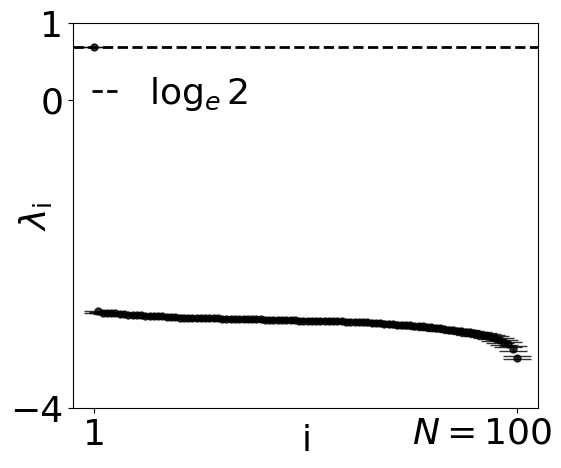

In [27]:
idx = np.linspace(1, 100, 100)
plt.figure(figsize=[6,5])

# Use asymmetric error bars
plt.errorbar(idx, med, yerr=[err_low, err_high],
             fmt='k.', ms=10, capsize=10, elinewidth=1, alpha=0.8)

plt.axhline(np.log(2), c='k', ls='--', lw=2, label='$\log_e 2$')
plt.legend(handlelength=.8, framealpha=0., loc='upper left', bbox_to_anchor=(-.03, 0.95) )
plt.ylabel('$\lambda_\\mathrm{i}$', labelpad=-32)
plt.xlabel('$\\mathrm{i}$', labelpad=-20)

ax = plt.gca()
plt.xticks([1, 100], ['1', ''])   # hide default label for 100
plt.yticks([1, 0, -4])

# choose one:
ax.annotate('$N=100$', xy=(100, 0), xycoords=('data','axes fraction'),
            xytext=(25, -6), textcoords='offset points', ha='right', va='top')

plt.gca().set_facecolor('none')
plt.gcf().patch.set_alpha(0)
plt.show()


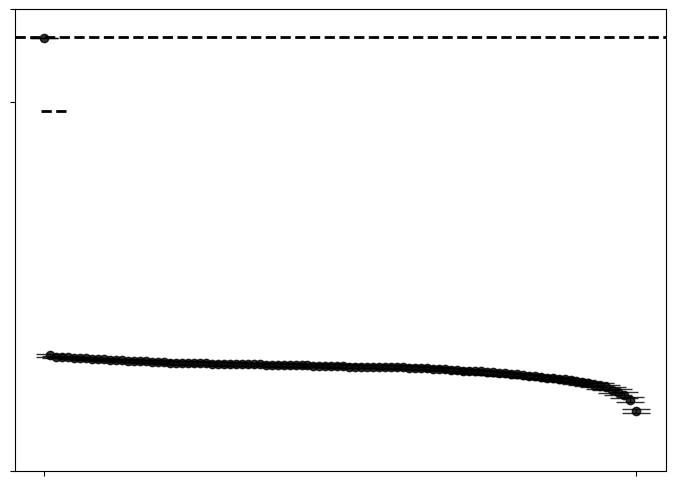

In [11]:
idx = np.linspace(1, 100, 100)
plt.figure(figsize=(8.4,6), facecolor='none')   # transparent figure background
ax = plt.gca()
ax.set_facecolor('none')                      # transparent axes background

# --- Plot data ---
plt.errorbar(idx, med, yerr=[err_low, err_high],
             fmt='k.', ms=12, capsize=10, elinewidth=1, alpha=0.8)

# --- Reference line with legend ---
plt.axhline(np.log(2), c='k', ls='--', lw=2, label=' ')
plt.legend(handlelength=.8, framealpha=0., loc='upper left',
           bbox_to_anchor=(-.01, 0.88))

# --- Remove axis labels ---
plt.xlabel('')
plt.ylabel('')

# --- Keep only min/max ticks, but no labels ---
plt.xticks([1, 100], ['', ''])
plt.yticks([1, 0, -4], ['','',''])

# --- Transparent background setup ---
ax.set_facecolor('none')
plt.gcf().patch.set_alpha(0)

plt.show()


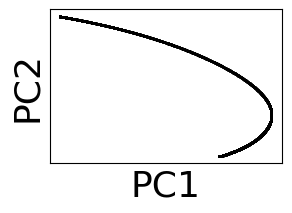

In [13]:
## dynamics of reservoir
prednum = 10**4 # int(T/dt/2)
preds_lyap = np.zeros((prednum, dim))

rss = np.zeros((prednum, h))
np.random.seed(10)
idx = 100

h = 100  # hidden width
kh = 0#1/100#10**-2.7
ki = 1.#5.#0.6
kb = ki#.01#1.7#0.2

Wh = kh * np.random.randn(h, h)  # hidden-to-hidden
Wi = ki * np.random.randn(h, dim)  # input-to-hidden
b = kb * np.random.randn(h, 1)  # hidden bias
rs = -np.sqrt(kh) + (2*np.sqrt(kh)) * np.random.rand(h, 1)

for i in range(convnum):
    rs = np.tanh(Wh @ rs + Wi @ strain[idx + i, :].reshape(-1, 1) + b)

pred = Wo @ rs
for i in range(prednum):
    rs = np.tanh(Wh @ rs + Wi @ pred + b)
    pred = Wo @ rs
    preds_lyap[i, :] = pred.flatten()[:dim]
    rss[i, :] = rs.flatten()

rs_svd, S_res, V_res = svd(rss, full_matrices=False)
# rs_svd, S_res, V_res = svd(s, full_matrices=False)

rs_svd = rs_svd.T


fig = plt.figure(figsize=[3,2])
plt.plot(rs_svd[0, :], rs_svd[1, :],'.',c='k',ms=1.)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.xticks([])
plt.yticks([])
plt.show()

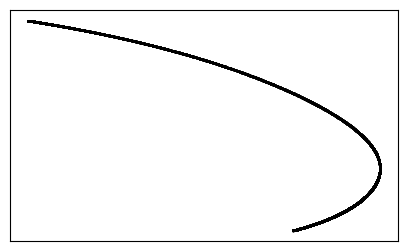

In [15]:
fig = plt.figure(figsize=[5,3])
fig.patch.set_alpha(0)        # Transparent figure background
ax = plt.gca()
ax.set_facecolor('none')      # Transparent axes background
plt.plot(rs_svd[0, :], rs_svd[1, :], '.', c='k', ms=1.5)
plt.xticks([])
plt.yticks([])
plt.show()



In [18]:
lyaptimemtx = np.load('../results_data/vpt_log_20251110_15.npy', allow_pickle=True)
distmtx = np.load('../results_data/dist_log_20251110_15.npy', allow_pickle=True)
khlist = np.load('../results_data/khlist_log_20251110_15.npy', allow_pickle=True)
kilist = np.load('../results_data/kilist_log_20251110_15.npy', allow_pickle=True)
lesmtx = np.load('../results_data/les_log_20251209_04.npy', allow_pickle=True)


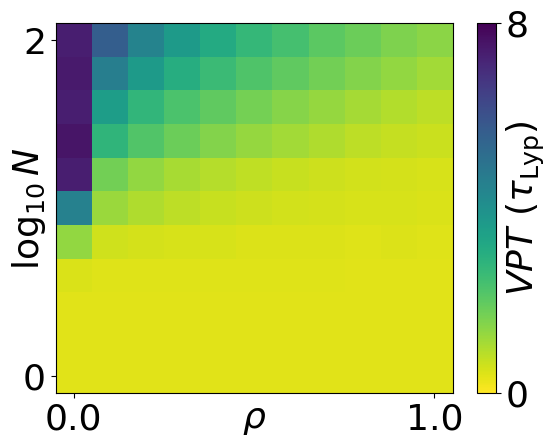

In [19]:
im = lyaptimemtx
plt.figure()
img = plt.imshow(im, aspect='auto', cmap='viridis_r',vmin=0,vmax=8)
cbar = plt.colorbar(img)

# --- Customize colorbar ticks ---
cbar.set_ticks([.0, 8])             # set custom tick positions
# cbar.set_ticklabels(['0', '5', '10', '15'])  # set custom labels

# --- Move colorbar label ---
cbar.set_label('$VPT\ (\\tau_\mathrm{Lyp})$', labelpad=-17)   # adjust padding
# cbar.ax.yaxis.set_label_position('left')         # move label to left
# cbar.ax.yaxis.set_label_position('right')      # move label to right (default)

plt.ylabel('$\log_{10} N$', labelpad=-18)
plt.xlabel('$\\rho$', labelpad=-24)

plt.xticks([0, len(khlist) - 1], [khlist[0], "{:.1f}".format(khlist[-1])])
plt.yticks([0, len(kilist) - 1], ["{:.0f}".format(np.log10(kilist[0])), "{:.0f}".format(np.log10(kilist[-1]))])

plt.gca().invert_yaxis()

plt.show()


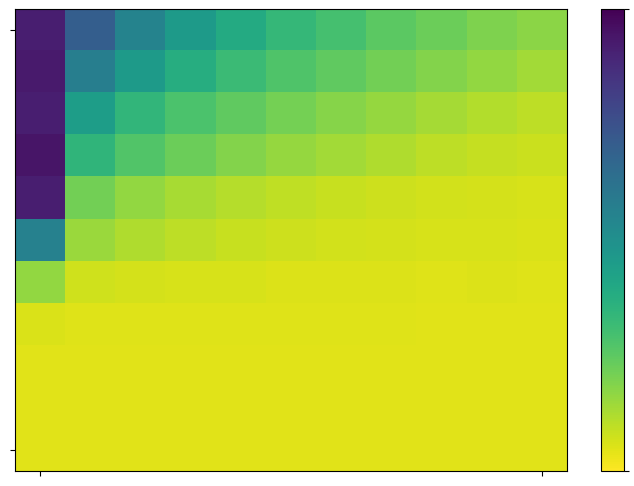

In [20]:
im = lyaptimemtx
plt.figure(figsize=(8.9,6),facecolor='none')   # transparent figure background
ax = plt.gca()
ax.set_facecolor('none')
img = plt.imshow(im, aspect='auto', cmap='viridis_r', vmin=0, vmax=8)
cbar = plt.colorbar(img)

# --- Keep min/max ticks but no labels on colorbar ---
cbar.set_ticks([0, 8])           # keep ticks at min and max
cbar.set_ticklabels([])          # remove tick labels
cbar.set_label('')               # remove colorbar label

# --- Remove axis labels ---
plt.xlabel('')
plt.ylabel('')

# --- Keep only min/max ticks, but remove their labels ---
plt.xticks([0, len(khlist) - 1], ['',''])  # positions: min/max, labels: empty
plt.yticks([0, len(kilist) - 1], ['',''])

plt.gca().invert_yaxis()

plt.show()


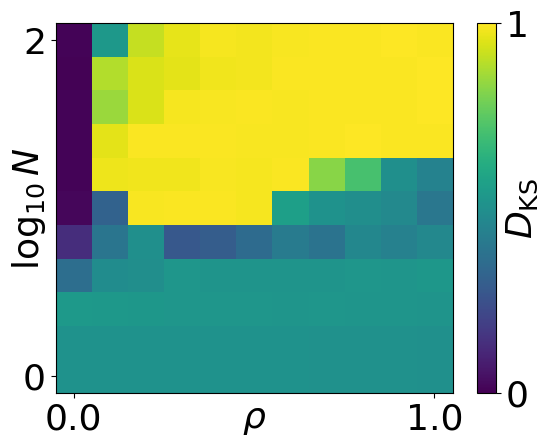

In [21]:
im = distmtx
plt.figure()
img = plt.imshow(im, aspect='auto',vmin=0,vmax=1)
cbar = plt.colorbar(img)

# --- Customize colorbar ticks ---
cbar.set_ticks([0, 1])             # set custom tick positions
# cbar.set_ticklabels(['0', '5', '10', '15'])  # set custom labels

# --- Move colorbar label ---
cbar.set_label('$D_\mathrm{KS}$', labelpad=-17)   # adjust padding
# cbar.ax.yaxis.set_label_position('left')         # move label to left
# cbar.ax.yaxis.set_label_position('right')      # move label to right (default)

plt.ylabel('$\log_{10} N$', labelpad=-18)
plt.xlabel('$\\rho$', labelpad=-24)

plt.xticks([0, len(khlist) - 1], [khlist[0], "{:.1f}".format(khlist[-1])])
plt.yticks([0, len(kilist) - 1], ["{:.0f}".format(np.log10(kilist[0])), "{:.0f}".format(np.log10(kilist[-1]))])

# plt.yticks([0, len(kilist)/2 - 1], [kilist[0], 1.])
# plt.ylim([5,0])

plt.gca().invert_yaxis()

plt.show()


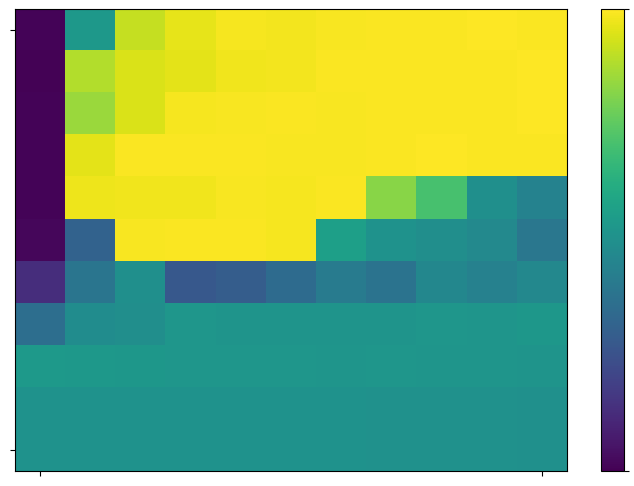

In [22]:
im = distmtx
plt.figure(figsize=(8.9,6),facecolor='none')   # transparent figure background
ax = plt.gca()
ax.set_facecolor('none')
img = plt.imshow(im, aspect='auto', vmin=0, vmax=1)
cbar = plt.colorbar(img)

# --- Keep only min/max ticks, but remove labels on colorbar ---
cbar.set_ticks([0, 1])          # keep ticks at min and max
cbar.set_ticklabels([])         # remove tick labels
cbar.set_label('')              # remove colorbar label

# --- Remove axis labels ---
plt.xlabel('')
plt.ylabel('')

# --- Keep only min/max ticks, but no labels ---
plt.xticks([0, len(khlist) - 1], ['', ''])
plt.yticks([0, len(kilist) - 1], ['', ''])

plt.gca().invert_yaxis()

plt.show()


# SI1

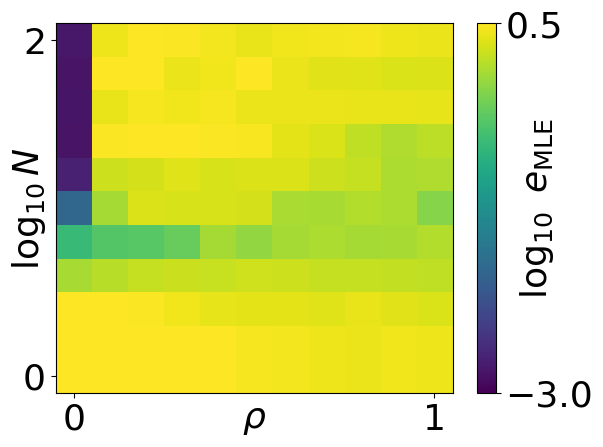

In [23]:
im = lesmtx
plt.figure()
img = plt.imshow(np.log10(im), aspect='auto',vmin=-3,vmax=.5)
# img = plt.imshow(im, aspect='auto')

cbar = plt.colorbar(img)

# --- Customize colorbar ticks ---
cbar.set_ticks([-3, .5])             # set custom tick positions
# cbar.set_ticklabels(['0', '5', '10', '15'])  # set custom labels

# --- Move colorbar label ---
cbar.set_label('$\log_{10}\ e_\mathrm{MLE}$', labelpad=-54)   # adjust padding
# cbar.ax.yaxis.set_label_position('left')         # move label to left
# cbar.ax.yaxis.set_label_position('right')      # move label to right (default)


plt.ylabel('$\log_{10} N$', labelpad=-18)
plt.xlabel('$\\rho$', labelpad=-24)

plt.xticks([0, len(khlist) - 1], ["{:.0f}".format(khlist[0]), "{:.0f}".format(khlist[-1])])
plt.yticks([0, len(kilist) - 1], ["{:.0f}".format(np.log10(kilist[0])), "{:.0f}".format(np.log10(kilist[-1]))])

# plt.yticks([0, len(kilist)/2 - 1], [kilist[0], 1.])
# plt.ylim([5,0])

plt.gca().invert_yaxis()

plt.show()


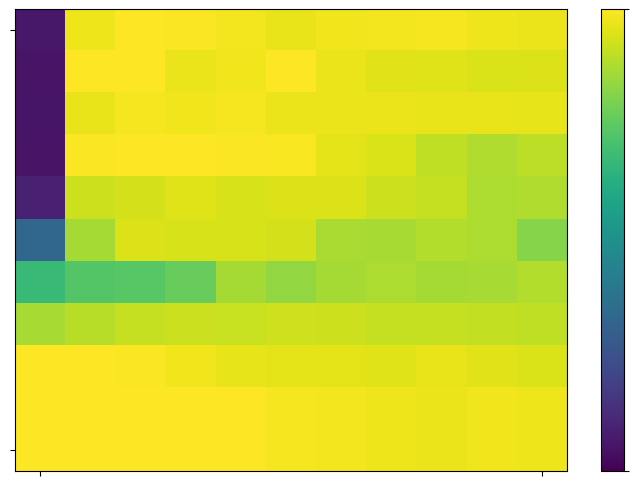

In [24]:
im = lesmtx
plt.figure(figsize=(8.9,6),facecolor='none')   # transparent figure background
ax = plt.gca()
ax.set_facecolor('none')
img = plt.imshow(np.log10(im), aspect='auto', vmin=-3,vmax=.5)
cbar = plt.colorbar(img)

# --- Keep only min/max ticks, but remove labels on colorbar ---
cbar.set_ticks([-3, .5])          # keep ticks at min and max
cbar.set_ticklabels([])         # remove tick labels
cbar.set_label('')              # remove colorbar label

# --- Remove axis labels ---
plt.xlabel('')
plt.ylabel('')

# --- Keep only min/max ticks, but no labels ---
plt.xticks([0, len(khlist) - 1], ['', ''])
plt.yticks([0, len(kilist) - 1], ['', ''])

plt.gca().invert_yaxis()

plt.show()
